# 🏦 FinGuard AI — Model Comparison & Optimization

### AI-Powered Financial Fraud Detection & Risk Intelligence Platform

**Notebook:** 06 — Model Comparison & Optimization  
**Project:** FinGuard AI

#### Objective

This notebook performs detailed comparison and optimization of the trained fraud-detection candidates.

Workflow:
- Load trained model artifacts
- Compare baseline performance
- Create development/validation split
- Hyperparameter optimization
- Threshold analysis
- Precision–Recall analysis
- Fraud threshold selection
- False-positive / false-negative analysis
- Final model selection
- Final untouched-test evaluation
- Save optimized model, threshold and metadata

**Important:** The untouched test set is not used for hyperparameter fitting or threshold selection.

In [1]:
# ============================================================
# 1. Environment Setup
# ============================================================

import sys
import warnings
from pathlib import Path
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
N_ITER = 8
CV_FOLDS = 3

print("FinGuard AI — Model Comparison & Optimization")
print("=" * 72)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

FinGuard AI — Model Comparison & Optimization
Python : 3.11.15
NumPy  : 2.4.6
Pandas : 3.0.5


#### 2. Project Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "Dataset"
PROCESSED_DIR = DATASET_DIR / "Processed"
MODEL_DIR = PROJECT_ROOT / "Models"
REPORT_DIR = PROJECT_ROOT / "Reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "feature_engineered_train.csv"
BALANCED_TRAIN_PATH = PROCESSED_DIR / "feature_engineered_train_balanced.csv"
TEST_PATH = PROCESSED_DIR / "feature_engineered_test.csv"

FEATURE_METADATA_PATH = MODEL_DIR / "feature_engineering_metadata.joblib"
TRAINING_METADATA_PATH = MODEL_DIR / "model_training_metadata.joblib"
PREVIOUS_RESULTS_PATH = REPORT_DIR / "model_comparison.csv"

MODEL_PATHS = {
    "Logistic Regression": MODEL_DIR / "logistic_regression_model.joblib",
    "Random Forest": MODEL_DIR / "random_forest_model.joblib",
    "XGBoost": MODEL_DIR / "xgboost_model.joblib",
    "HistGradientBoosting": MODEL_DIR / "hist_gradient_boosting_model.joblib"
}

print("Project Root :", PROJECT_ROOT)
print("Processed    :", PROCESSED_DIR)
print("Models       :", MODEL_DIR)
print("Reports      :", REPORT_DIR)

Project Root : C:\Users\viqua\Desktop\FinGuard AI
Processed    : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed
Models       : C:\Users\viqua\Desktop\FinGuard AI\Models
Reports      : C:\Users\viqua\Desktop\FinGuard AI\Reports


#### 3. Input Artifact Validation

In [3]:
required_files = [
    TRAIN_PATH, BALANCED_TRAIN_PATH, TEST_PATH,
    FEATURE_METADATA_PATH, TRAINING_METADATA_PATH,
    PREVIOUS_RESULTS_PATH, *MODEL_PATHS.values()
]

print("Required artifacts")
print("=" * 72)

for path in required_files:
    print(f"{'✓ EXISTS' if path.exists() else '✗ MISSING':12} {path}")

missing = [p for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("One or more Notebook 05 artifacts are missing.")

print("\n✓ Input artifact validation passed")

Required artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train_balanced.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\feature_engineering_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\model_training_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\model_comparison.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\logistic_regression_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\random_forest_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\xgboost_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\hist_gradient_boosting_model.joblib

✓ Input artifact validation passed


#### 4. Load Feature-Engineered Data and Previous Results

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
balanced_train_df = pd.read_csv(BALANCED_TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
previous_results_df = pd.read_csv(PREVIOUS_RESULTS_PATH)

TARGET = "Class"
feature_columns = [c for c in train_df.columns if c != TARGET]

if TARGET not in balanced_train_df.columns or TARGET not in test_df.columns:
    raise KeyError(f"Target column '{TARGET}' must exist in all datasets.")

if feature_columns != [c for c in test_df.columns if c != TARGET]:
    raise ValueError("Training and testing feature order does not match.")

if feature_columns != [c for c in balanced_train_df.columns if c != TARGET]:
    raise ValueError("Balanced and original training feature order does not match.")

print("Original training samples :", f"{len(train_df):,}")
print("Balanced training samples :", f"{len(balanced_train_df):,}")
print("Testing samples           :", f"{len(test_df):,}")
print("Feature count             :", len(feature_columns))
print("Target                    :", TARGET)
print("✓ Feature consistency validated")

Original training samples : 226,980
Balanced training samples : 453,204
Testing samples           : 56,746
Feature count             : 53
Target                    : Class
✓ Feature consistency validated


#### 5. Previous Model Comparison

In [5]:
display(
    previous_results_df.style.format({
        "Accuracy":"{:.4f}", "Precision":"{:.4f}", "Recall":"{:.4f}",
        "F1_Score":"{:.4f}", "ROC_AUC":"{:.4f}", "PR_AUC":"{:.4f}",
        "Training_Time_Seconds":"{:.2f}"
    })
)

previous_best = previous_results_df.sort_values(
    ["F1_Score","PR_AUC","Recall"], ascending=False
).iloc[0]

print(f"Previous best candidate: {previous_best['Model']}")

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Training_Time_Seconds
0,Random Forest,0.9995,0.9324,0.7263,0.8166,0.9703,0.8004,1486.81
1,XGBoost,0.9991,0.7212,0.7895,0.7538,0.9703,0.8141,51.58
2,HistGradientBoosting,0.9987,0.5865,0.8211,0.6842,0.9680,0.8138,55.16
3,Logistic Regression,0.9700,0.0468,0.8737,0.0889,0.9608,0.6574,146.84


Previous best candidate: Random Forest


#### 6. Development / Validation Split

The balanced training data is divided into development and internal validation sets.

The validation set is used for optimization and threshold selection.

The untouched test set remains reserved for final evaluation.

In [6]:
X_balanced = balanced_train_df[feature_columns].copy()
y_balanced = balanced_train_df[TARGET].astype(int).copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

X_dev, X_valid, y_dev, y_valid = train_test_split(
    X_balanced, y_balanced,
    test_size=0.20,
    stratify=y_balanced,
    random_state=RANDOM_STATE
)

print("Development samples :", f"{len(X_dev):,}")
print("Validation samples  :", f"{len(X_valid):,}")
print("Test samples        :", f"{len(X_test):,}")
print("✓ Test set remains untouched")

Development samples : 362,563
Validation samples  : 90,641
Test samples        : 56,746
✓ Test set remains untouched


#### 7. Load Trained Models

In [7]:
trained_models = {}

for name, path in MODEL_PATHS.items():
    trained_models[name] = joblib.load(path)
    print(f"✓ Loaded: {name}")

print("\n✓ All trained model artifacts loaded")

✓ Loaded: Logistic Regression
✓ Loaded: Random Forest
✓ Loaded: XGBoost
✓ Loaded: HistGradientBoosting

✓ All trained model artifacts loaded


#### 8. Evaluation Utilities

In [8]:
def evaluate_probabilities(y_true, probabilities, threshold=0.50):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1_Score": f1_score(y_true, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "PR_AUC": average_precision_score(y_true, probabilities)
    }

validation_baseline = []

for name, model in trained_models.items():
    prob = model.predict_proba(X_valid)[:, 1]
    metrics = evaluate_probabilities(y_valid, prob, 0.50)
    metrics["Model"] = name
    metrics["Threshold"] = 0.50
    validation_baseline.append(metrics)

validation_baseline_df = pd.DataFrame(validation_baseline).sort_values(
    ["F1_Score","PR_AUC","Recall"], ascending=False
).reset_index(drop=True)

display(validation_baseline_df.style.format({
    "Accuracy":"{:.4f}", "Precision":"{:.4f}", "Recall":"{:.4f}",
    "F1_Score":"{:.4f}", "ROC_AUC":"{:.4f}", "PR_AUC":"{:.4f}",
    "Threshold":"{:.2f}"
}))

,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Model,Threshold
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,Random Forest,0.50
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,XGBoost,0.50
2,0.9998,0.9996,1.0000,0.9998,1.0000,1.0000,HistGradientBoosting,0.50
3,0.9467,0.9693,0.9225,0.9453,0.9878,0.9900,Logistic Regression,0.50


#### 9. Hyperparameter Optimization

In [9]:
optimization_spaces = {
    "Logistic Regression": {
        "C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "n_estimators": [200, 300, 400],
        "max_depth": [None, 12, 18, 24],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
        "class_weight": [None, "balanced"]
    },
    "XGBoost": {
        "n_estimators": [200, 300, 400],
        "max_depth": [4, 5, 6, 8],
        "learning_rate": [0.03, 0.05, 0.08, 0.10],
        "subsample": [0.75, 0.85, 1.0],
        "colsample_bytree": [0.75, 0.85, 1.0],
        "min_child_weight": [1, 3, 5]
    },
    "HistGradientBoosting": {
        "learning_rate": [0.03, 0.05, 0.08, 0.10],
        "max_iter": [100, 150, 200],
        "max_leaf_nodes": [15, 31, 63],
        "min_samples_leaf": [20, 30, 50],
        "l2_regularization": [0.0, 0.5, 1.0, 2.0]
    }
}

optimized_models = {}
optimization_records = []

for name, model in trained_models.items():

    print(f"\nOptimizing: {name}")
    print("-" * 72)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=optimization_spaces[name],
        n_iter=N_ITER,
        scoring="f1",
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True
    )

    start = time.time()
    search.fit(X_dev, y_dev)
    elapsed = time.time() - start

    optimized_models[name] = search.best_estimator_

    valid_prob = search.best_estimator_.predict_proba(X_valid)[:, 1]
    metrics = evaluate_probabilities(y_valid, valid_prob, 0.50)

    optimization_records.append({
        "Model": name,
        "Best_CV_F1": search.best_score_,
        "Validation_F1": metrics["F1_Score"],
        "Validation_PR_AUC": metrics["PR_AUC"],
        "Validation_Recall": metrics["Recall"],
        "Validation_Precision": metrics["Precision"],
        "Optimization_Time_Seconds": elapsed,
        "Best_Params": str(search.best_params_)
    })

    print(f"✓ Completed in {elapsed:.2f} seconds")
    print(f"Best CV F1 : {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")


Optimizing: Logistic Regression
------------------------------------------------------------------------
✓ Completed in 164.55 seconds
Best CV F1 : 0.9359
Best Params: {'solver': 'liblinear', 'class_weight': 'balanced', 'C': 0.1}

Optimizing: Random Forest
------------------------------------------------------------------------
✓ Completed in 6845.51 seconds
Best CV F1 : 0.9999
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}

Optimizing: XGBoost
------------------------------------------------------------------------
✓ Completed in 364.08 seconds
Best CV F1 : 0.9997
Best Params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.85}

Optimizing: HistGradientBoosting
------------------------------------------------------------------------
✓ Completed in 295.84 seconds
Best CV F1 : 0.9997
Best Params: {'min_samples_lea

#### 10. Optimization Results

In [10]:
optimization_df = pd.DataFrame(optimization_records).sort_values(
    ["Validation_F1","Validation_PR_AUC","Validation_Recall"],
    ascending=False
).reset_index(drop=True)

display(optimization_df.style.format({
    "Best_CV_F1":"{:.4f}",
    "Validation_F1":"{:.4f}",
    "Validation_PR_AUC":"{:.4f}",
    "Validation_Recall":"{:.4f}",
    "Validation_Precision":"{:.4f}",
    "Optimization_Time_Seconds":"{:.2f}"
}))

,Model,Best_CV_F1,Validation_F1,Validation_PR_AUC,Validation_Recall,Validation_Precision,Optimization_Time_Seconds,Best_Params
0,Random Forest,0.9999,0.9999,1.0000,1.0000,0.9999,6845.51,"{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}"
1,XGBoost,0.9997,0.9999,1.0000,1.0000,0.9997,364.08,"{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.85}"
2,HistGradientBoosting,0.9997,0.9997,0.9999,0.9999,0.9995,295.84,"{'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 200, 'learning_rate': 0.08, 'l2_regularization': 0.0}"
3,Logistic Regression,0.9359,0.9315,0.9856,0.8815,0.9874,164.55,"{'solver': 'liblinear', 'class_weight': 'balanced', 'C': 0.1}"


#### 11. Threshold Analysis

In [11]:
threshold_values = np.arange(0.10, 0.91, 0.02)
threshold_records = []

for name, model in optimized_models.items():

    probabilities = model.predict_proba(X_valid)[:, 1]

    for threshold in threshold_values:

        predictions = (probabilities >= threshold).astype(int)

        threshold_records.append({
            "Model": name,
            "Threshold": threshold,
            "Precision": precision_score(y_valid, predictions, zero_division=0),
            "Recall": recall_score(y_valid, predictions, zero_division=0),
            "F1_Score": f1_score(y_valid, predictions, zero_division=0)
        })

threshold_df = pd.DataFrame(threshold_records)

best_threshold_rows = (
    threshold_df.sort_values(
        ["Model","F1_Score","Recall","Precision"],
        ascending=[True,False,False,False]
    )
    .groupby("Model", as_index=False)
    .first()
)

display(best_threshold_rows.style.format({
    "Threshold":"{:.2f}",
    "Precision":"{:.4f}",
    "Recall":"{:.4f}",
    "F1_Score":"{:.4f}"
}))

,Model,Threshold,Precision,Recall,F1_Score
0,HistGradientBoosting,0.86,0.9999,0.9998,0.9999
1,Logistic Regression,0.32,0.9677,0.9081,0.9369
2,Random Forest,0.64,0.9999,1.0000,1.0000
3,XGBoost,0.82,0.9999,1.0000,1.0000


#### 12. Precision–Recall Analysis

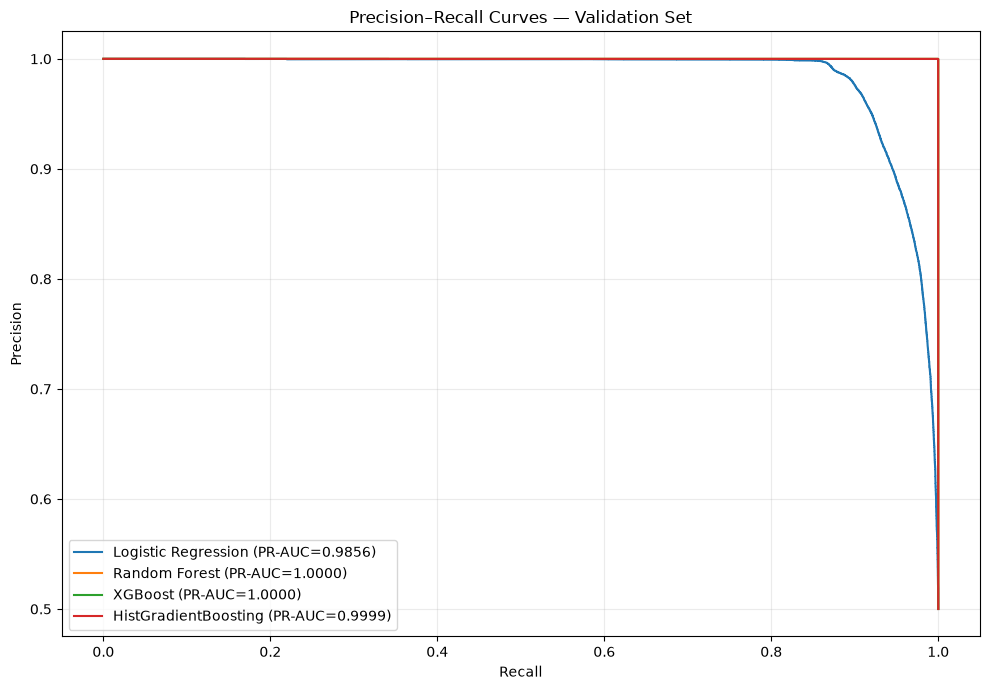

In [12]:
plt.figure(figsize=(10, 7))

for name, model in optimized_models.items():

    probabilities = model.predict_proba(X_valid)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_valid, probabilities
    )

    pr_auc = average_precision_score(
        y_valid, probabilities
    )

    plt.plot(
        recall, precision,
        label=f"{name} (PR-AUC={pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Validation Set")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### 13. Fraud Detection Threshold Selection

In [13]:
threshold_candidates = []

for name in optimized_models:

    rows = threshold_df[threshold_df["Model"] == name].copy()

    # Maintain strong recall when possible, then maximize F1.
    recall_constrained = rows[rows["Recall"] >= 0.80]

    if len(recall_constrained):
        selected = recall_constrained.sort_values(
            ["F1_Score","Precision","Recall"],
            ascending=False
        ).iloc[0]
    else:
        selected = rows.sort_values(
            ["F1_Score","Recall","Precision"],
            ascending=False
        ).iloc[0]

    threshold_candidates.append({
        "Model": name,
        "Selected_Threshold": selected["Threshold"],
        "Validation_Precision": selected["Precision"],
        "Validation_Recall": selected["Recall"],
        "Validation_F1": selected["F1_Score"]
    })

threshold_selection_df = pd.DataFrame(threshold_candidates).sort_values(
    ["Validation_F1","Validation_Recall","Validation_Precision"],
    ascending=False
).reset_index(drop=True)

display(threshold_selection_df.style.format({
    "Selected_Threshold":"{:.2f}",
    "Validation_Precision":"{:.4f}",
    "Validation_Recall":"{:.4f}",
    "Validation_F1":"{:.4f}"
}))

,Model,Selected_Threshold,Validation_Precision,Validation_Recall,Validation_F1
0,Random Forest,0.64,0.9999,1.0000,1.0000
1,XGBoost,0.82,0.9999,1.0000,1.0000
2,HistGradientBoosting,0.86,0.9999,0.9998,0.9999
3,Logistic Regression,0.32,0.9677,0.9081,0.9369


#### 14. False-Positive / False-Negative Analysis

In [14]:
error_records = []

for _, row in threshold_selection_df.iterrows():

    name = row["Model"]
    threshold = row["Selected_Threshold"]

    probabilities = optimized_models[name].predict_proba(X_valid)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid, predictions
    ).ravel()

    error_records.append({
        "Model": name,
        "Threshold": threshold,
        "True_Negative": tn,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Positive": tp
    })

error_analysis_df = pd.DataFrame(error_records)
display(error_analysis_df)

,Model,Threshold,True_Negative,False_Positive,False_Negative,True_Positive
0,Random Forest,0.64,45318,3,1,45319
1,XGBoost,0.82,45318,3,1,45319
2,HistGradientBoosting,0.86,45316,5,8,45312
3,Logistic Regression,0.32,43948,1373,4167,41153


#### 15. Final Candidate Ranking

In [15]:
candidate_ranking = threshold_selection_df.merge(
    optimization_df[
        ["Model","Best_CV_F1","Validation_PR_AUC"]
    ],
    on="Model",
    how="left"
)

candidate_ranking = candidate_ranking.sort_values(
    ["Validation_F1","Validation_PR_AUC","Validation_Recall","Validation_Precision"],
    ascending=False
).reset_index(drop=True)

display(candidate_ranking.style.format({
    "Selected_Threshold":"{:.2f}",
    "Validation_Precision":"{:.4f}",
    "Validation_Recall":"{:.4f}",
    "Validation_F1":"{:.4f}",
    "Best_CV_F1":"{:.4f}",
    "Validation_PR_AUC":"{:.4f}"
}))

final_model_name = candidate_ranking.iloc[0]["Model"]
final_model = optimized_models[final_model_name]
final_threshold = float(candidate_ranking.iloc[0]["Selected_Threshold"])

print(f"\n🏆 Final deployment candidate: {final_model_name}")
print(f"Selected fraud threshold: {final_threshold:.2f}")

,Model,Selected_Threshold,Validation_Precision,Validation_Recall,Validation_F1,Best_CV_F1,Validation_PR_AUC
0,XGBoost,0.82,0.9999,1.0000,1.0000,0.9997,1.0000
1,Random Forest,0.64,0.9999,1.0000,1.0000,0.9999,1.0000
2,HistGradientBoosting,0.86,0.9999,0.9998,0.9999,0.9997,0.9999
3,Logistic Regression,0.32,0.9677,0.9081,0.9369,0.9359,0.9856



🏆 Final deployment candidate: XGBoost
Selected fraud threshold: 0.82


#### 16. Final Candidate Validation

In [16]:
final_valid_probabilities = final_model.predict_proba(X_valid)[:, 1]
final_valid_predictions = (final_valid_probabilities >= final_threshold).astype(int)

final_validation_metrics = {
    "Model": final_model_name,
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_valid, final_valid_predictions),
    "Precision": precision_score(y_valid, final_valid_predictions, zero_division=0),
    "Recall": recall_score(y_valid, final_valid_predictions, zero_division=0),
    "F1_Score": f1_score(y_valid, final_valid_predictions, zero_division=0),
    "ROC_AUC": roc_auc_score(y_valid, final_valid_probabilities),
    "PR_AUC": average_precision_score(y_valid, final_valid_probabilities)
}

display(pd.DataFrame([final_validation_metrics]).style.format({
    "Threshold":"{:.2f}", "Accuracy":"{:.4f}", "Precision":"{:.4f}",
    "Recall":"{:.4f}", "F1_Score":"{:.4f}", "ROC_AUC":"{:.4f}", "PR_AUC":"{:.4f}"
}))

,Model,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,XGBoost,0.82,1.0000,0.9999,1.0000,1.0000,1.0000,1.0000


#### 17. Final Evaluation on Untouched Test Set

In [17]:
# No optimization or threshold selection is performed on this test set.

final_test_probabilities = final_model.predict_proba(X_test)[:, 1]
final_test_predictions = (final_test_probabilities >= final_threshold).astype(int)

final_test_metrics = {
    "Model": final_model_name,
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, final_test_predictions),
    "Precision": precision_score(y_test, final_test_predictions, zero_division=0),
    "Recall": recall_score(y_test, final_test_predictions, zero_division=0),
    "F1_Score": f1_score(y_test, final_test_predictions, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, final_test_probabilities),
    "PR_AUC": average_precision_score(y_test, final_test_probabilities)
}

final_test_df = pd.DataFrame([final_test_metrics])

display(final_test_df.style.format({
    "Threshold":"{:.2f}", "Accuracy":"{:.4f}", "Precision":"{:.4f}",
    "Recall":"{:.4f}", "F1_Score":"{:.4f}", "ROC_AUC":"{:.4f}", "PR_AUC":"{:.4f}"
}))

print("✓ Final evaluation completed on untouched test data")

,Model,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,XGBoost,0.82,0.9995,0.8902,0.7684,0.8249,0.9706,0.8162


✓ Final evaluation completed on untouched test data


#### 18. Final Confusion Matrix

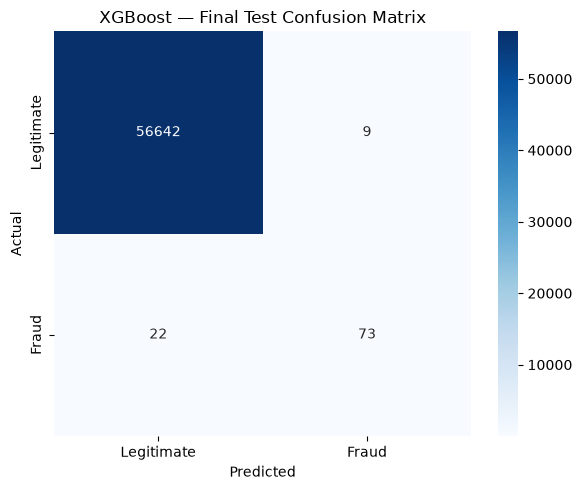

Final test error analysis
--------------------------------------------------
True Negatives : 56,642
False Positives: 9
False Negatives: 22
True Positives : 73


In [18]:
final_cm = confusion_matrix(y_test, final_test_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)
plt.title(f"{final_model_name} — Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = final_cm.ravel()

print("Final test error analysis")
print("-" * 50)
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives : {tp:,}")

#### 19. Final Classification Report

In [19]:
print(f"Classification Report — {final_model_name}")
print("=" * 72)

print(classification_report(
    y_test,
    final_test_predictions,
    target_names=["Legitimate","Fraud"],
    digits=4,
    zero_division=0
))

Classification Report — XGBoost
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56651
       Fraud     0.8902    0.7684    0.8249        95

    accuracy                         0.9995     56746
   macro avg     0.9449    0.8841    0.9123     56746
weighted avg     0.9994    0.9995    0.9994     56746



#### 20. Save Optimized Model

In [20]:
optimized_model_path = MODEL_DIR / "optimized_fraud_model.joblib"

joblib.dump(
    final_model,
    optimized_model_path
)

print(f"✓ Optimized model saved: {optimized_model_path}")

✓ Optimized model saved: C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib


#### 21. Save Fraud Threshold Metadata

In [21]:
threshold_metadata = {
    "project": "FinGuard AI",
    "target": TARGET,
    "model": final_model_name,
    "fraud_threshold": final_threshold,
    "threshold_selection_metric": "F1 with recall priority",
    "validation_samples": int(len(X_valid)),
    "test_samples": int(len(X_test)),
    "test_set_used_for_threshold_selection": False
}

threshold_path = MODEL_DIR / "fraud_threshold_metadata.joblib"

joblib.dump(
    threshold_metadata,
    threshold_path
)

print(f"✓ Threshold metadata saved: {threshold_path}")

✓ Threshold metadata saved: C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib


#### 22. Save Optimization and Evaluation Reports

In [22]:
optimization_results_path = REPORT_DIR / "model_optimization_results.csv"
threshold_results_path = REPORT_DIR / "threshold_analysis.csv"
error_results_path = REPORT_DIR / "false_positive_negative_analysis.csv"
final_test_results_path = REPORT_DIR / "final_model_evaluation.csv"

optimization_df.to_csv(optimization_results_path, index=False)
threshold_df.to_csv(threshold_results_path, index=False)
error_analysis_df.to_csv(error_results_path, index=False)
final_test_df.to_csv(final_test_results_path, index=False)

print(f"✓ Saved: {optimization_results_path}")
print(f"✓ Saved: {threshold_results_path}")
print(f"✓ Saved: {error_results_path}")
print(f"✓ Saved: {final_test_results_path}")

✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\model_optimization_results.csv
✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\threshold_analysis.csv
✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\false_positive_negative_analysis.csv
✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\final_model_evaluation.csv


#### 23. Save Final Model Metadata

In [23]:
final_metadata = {
    "project": "FinGuard AI",
    "target": TARGET,
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "candidate_models": list(optimized_models.keys()),
    "selected_model": final_model_name,
    "fraud_threshold": final_threshold,
    "optimization_method": "RandomizedSearchCV",
    "optimization_scoring": "f1",
    "cv_folds": CV_FOLDS,
    "optimization_iterations_per_model": N_ITER,
    "balanced_training_samples": int(len(X_balanced)),
    "development_samples": int(len(X_dev)),
    "validation_samples": int(len(X_valid)),
    "testing_samples": int(len(X_test)),
    "test_set_used_for_optimization": False,
    "test_set_used_for_threshold_selection": False,
    "final_test_metrics": final_test_metrics
}

final_metadata_path = MODEL_DIR / "final_model_metadata.joblib"

joblib.dump(
    final_metadata,
    final_metadata_path
)

print(f"✓ Final metadata saved: {final_metadata_path}")

✓ Final metadata saved: C:\Users\viqua\Desktop\FinGuard AI\Models\final_model_metadata.joblib


#### 24. Final Artifact Validation

In [24]:
expected_artifacts = [
    MODEL_DIR / "optimized_fraud_model.joblib",
    MODEL_DIR / "fraud_threshold_metadata.joblib",
    MODEL_DIR / "final_model_metadata.joblib",
    REPORT_DIR / "model_optimization_results.csv",
    REPORT_DIR / "threshold_analysis.csv",
    REPORT_DIR / "false_positive_negative_analysis.csv",
    REPORT_DIR / "final_model_evaluation.csv"
]

print("Generated Optimization Artifacts")
print("=" * 72)

for path in expected_artifacts:
    print(f"{'✓ EXISTS' if path.exists() else '✗ MISSING':12} {path}")

if not all(path.exists() for path in expected_artifacts):
    raise RuntimeError("One or more optimization artifacts were not created.")

print("\n✓ Optimization artifact validation passed")

Generated Optimization Artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\final_model_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\model_optimization_results.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\threshold_analysis.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\false_positive_negative_analysis.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\final_model_evaluation.csv

✓ Optimization artifact validation passed


#### 25. Model Optimization Summary

In [25]:
print("=" * 75)
print("FIN GUARD AI — MODEL COMPARISON & OPTIMIZATION SUMMARY")
print("=" * 75)

print(f"✓ Features Used              : {len(feature_columns)}")
print(f"✓ Candidate Models           : {len(optimized_models)}")
print(f"✓ Development Samples        : {len(X_dev):,}")
print(f"✓ Validation Samples         : {len(X_valid):,}")
print(f"✓ Testing Samples            : {len(X_test):,}")
print(f"✓ Final Model                : {final_model_name}")
print(f"✓ Fraud Threshold            : {final_threshold:.2f}")
print(f"✓ Final Precision            : {final_test_metrics['Precision']:.4f}")
print(f"✓ Final Recall               : {final_test_metrics['Recall']:.4f}")
print(f"✓ Final F1-score             : {final_test_metrics['F1_Score']:.4f}")
print(f"✓ Final PR-AUC               : {final_test_metrics['PR_AUC']:.4f}")
print(f"✓ Final ROC-AUC              : {final_test_metrics['ROC_AUC']:.4f}")
print("✓ Test Set Used for Tuning   : No")
print("✓ Test Set Used for Threshold: No")
print("✓ Optimized Model            : Saved")
print("✓ Threshold Metadata         : Saved")
print("=" * 75)
print("✓ NOTEBOOK 06 MODEL COMPARISON & OPTIMIZATION COMPLETED")
print("=" * 75)

FIN GUARD AI — MODEL COMPARISON & OPTIMIZATION SUMMARY
✓ Features Used              : 53
✓ Candidate Models           : 4
✓ Development Samples        : 362,563
✓ Validation Samples         : 90,641
✓ Testing Samples            : 56,746
✓ Final Model                : XGBoost
✓ Fraud Threshold            : 0.82
✓ Final Precision            : 0.8902
✓ Final Recall               : 0.7684
✓ Final F1-score             : 0.8249
✓ Final PR-AUC               : 0.8162
✓ Final ROC-AUC              : 0.9706
✓ Test Set Used for Tuning   : No
✓ Test Set Used for Threshold: No
✓ Optimized Model            : Saved
✓ Threshold Metadata         : Saved
✓ NOTEBOOK 06 MODEL COMPARISON & OPTIMIZATION COMPLETED


#### 26. Next Stage

### Notebook 07 — Final Model & Prediction

The next notebook will perform:

- Loading the optimized fraud model
- Loading the saved fraud threshold
- Preparing prediction input
- Generating fraud probability / risk score
- Applying the selected fraud threshold
- Producing prediction results
- Preparing artifacts for the application layer

**Important:** The optimized model and saved threshold generated here are the deployment candidates for the next stage.